# 04 Numerical Features (E-13 to E-18)

**Data used:** the development set.  
**Questions:** Q10 skew and zero inflation, Q11 correlations, Q14 linearity, Q16 extremes (DOC-02 §4.4, §4.5).

All computation lives in `house_price.eda` (FR-010): this notebook only runs it and shows the saved outputs (`reports/eda/`, `reports/figures/eda/`).

In [1]:
from IPython.display import Image, Markdown, display

from house_price.eda import EDAContext
from house_price.eda import numeric

ctx = EDAContext.load()  # validated raw file + persisted development set (never the held-out rows)

In [2]:
outputs = numeric.run(ctx)
sorted(outputs.tables) + sorted(outputs.figures)

['E-13_numeric_profile',
 'E-15_target_correlation',
 'E-16_correlated_pairs',
 'E-17_overallqual_price_profile',
 'E-18_numeric_extremes',
 'E-14_numeric_distributions',
 'E-16_correlation_heatmap',
 'E-17_top_predictor_scatter']

## E-13 Numeric profile: statistics, skewness, share of zeros, distinct values.

In [3]:
outputs.tables["E-13_numeric_profile"]

,feature,n,n_missing,min,q1,median,mean,q3,max,std,skewness,share_zero,n_distinct,top_value_share
0,LotFrontage,1958,382,21.0,59.00,68.0,69.179265,80.00,313.0,22.926200,1.239463,0.000000,124,0.112870
1,LotArea,2340,0,1300.0,7448.25,9374.0,10109.794017,11426.00,215245.0,7826.737340,12.901058,0.000000,1622,0.016667
2,OverallQual,2340,0,1.0,5.00,6.0,6.081624,7.00,10.0,1.406546,0.222141,0.000000,10,0.280769
3,OverallCond,2340,0,1.0,5.00,5.0,5.558974,6.00,9.0,1.112497,0.626164,0.000000,9,0.569658
4,YearBuilt,2340,0,1872.0,1953.00,1972.0,1970.820940,2001.00,2010.0,30.612711,-0.591670,0.000000,117,0.050000
5,YearRemodAdd,2340,0,1950.0,1964.00,1993.0,1983.974359,2004.00,2010.0,21.052881,-0.429217,0.000000,61,0.126923
6,MasVnrArea,2324,16,0.0,0.00,0.0,101.365749,164.25,1378.0,175.182523,2.434635,0.601119,396,0.601119
7,BsmtFinSF1,2339,1,0.0,0.00,360.0,436.112441,734.50,2288.0,441.194828,0.838111,0.325353,882,0.325353
8,BsmtFinSF2,2339,1,0.0,0.00,0.0,47.647713,0.00,1474.0,164.512076,4.182812,0.884139,226,0.884139
9,BsmtUnfSF,2339,1,0.0,221.50,480.0,564.430098,812.50,2336.0,438.917663,0.891231,0.079949,1035,0.079949


## E-14 Distribution grid.

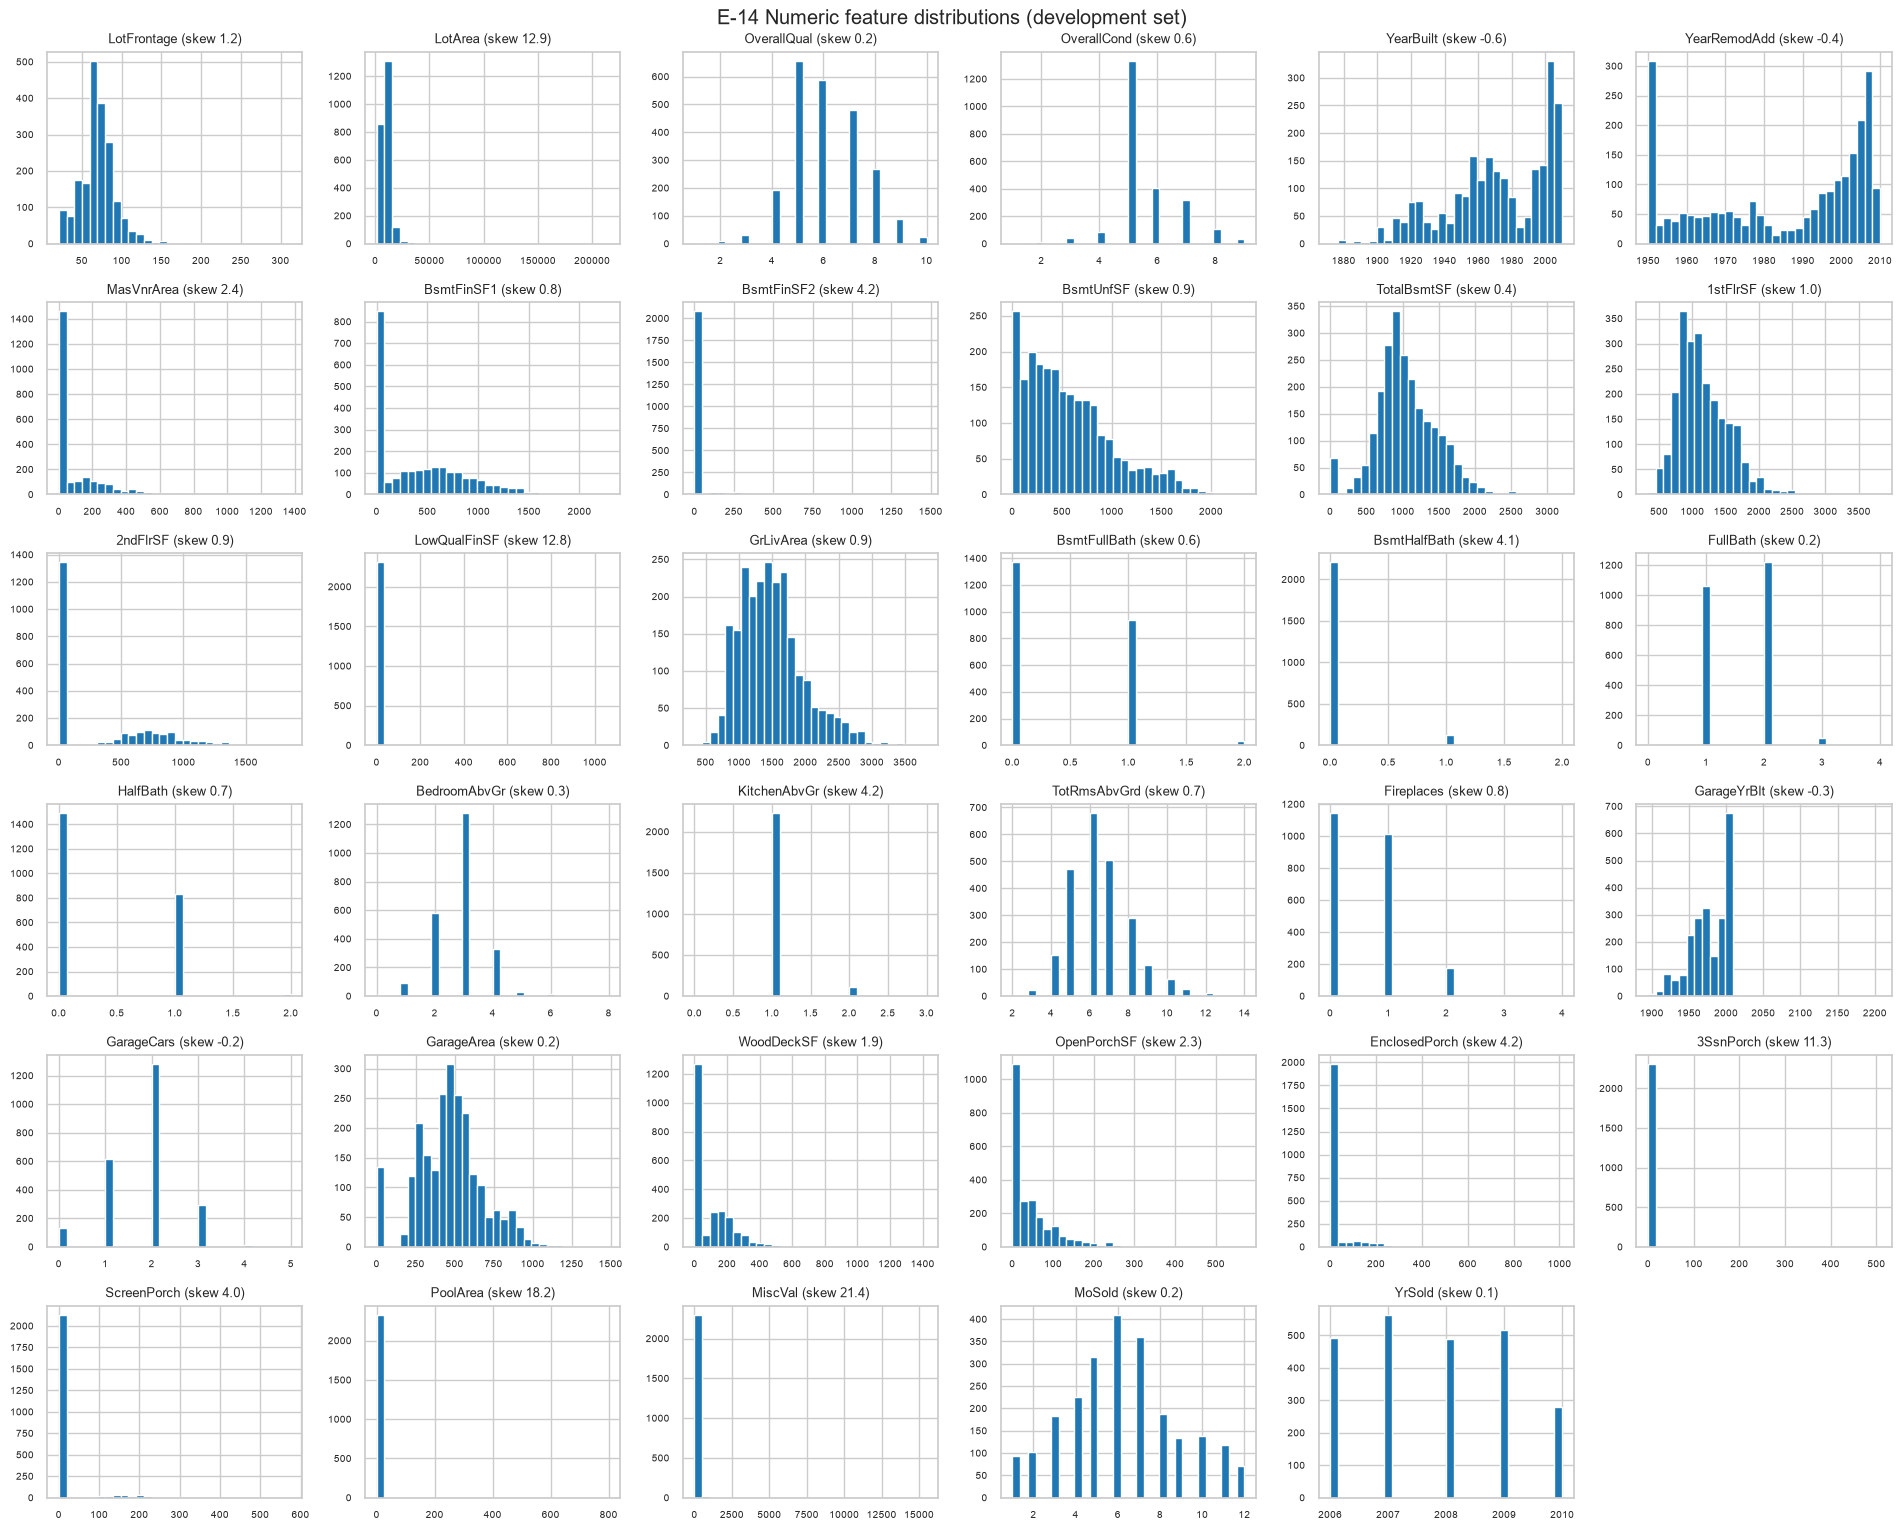

In [4]:
Image(filename=outputs.figures["E-14_numeric_distributions"])

## E-15 Correlation with log price, ranked by |Spearman|.

In [5]:
outputs.tables["E-15_target_correlation"]

,rank,feature,pearson,spearman
0,1,OverallQual,0.830236,0.811849
1,2,GrLivArea,0.713046,0.718907
2,3,GarageCars,0.683793,0.705395
3,4,YearBuilt,0.607954,0.675586
4,5,GarageArea,0.663270,0.663442
5,6,FullBath,0.578390,0.635758
6,7,GarageYrBlt,0.566835,0.630577
7,8,YearRemodAdd,0.589623,0.603761
8,9,TotalBsmtSF,0.648024,0.603110
9,10,1stFlrSF,0.623125,0.584328


## E-16 Strongly correlated pairs and the top-15 heatmap.

In [6]:
outputs.tables["E-16_correlated_pairs"]

,feature_a,feature_b,pearson,strong
0,GarageCars,GarageArea,0.894649,True
1,YearBuilt,GarageYrBlt,0.832937,True
2,GrLivArea,TotRmsAbvGrd,0.809863,True
3,TotalBsmtSF,1stFlrSF,0.787302,True
4,BedroomAbvGr,TotRmsAbvGrd,0.671156,False
5,2ndFlrSF,GrLivArea,0.659767,False
6,BsmtFinSF1,BsmtFullBath,0.649545,False
7,YearRemodAdd,GarageYrBlt,0.649251,False
8,GrLivArea,FullBath,0.636494,False
9,2ndFlrSF,HalfBath,0.613206,False


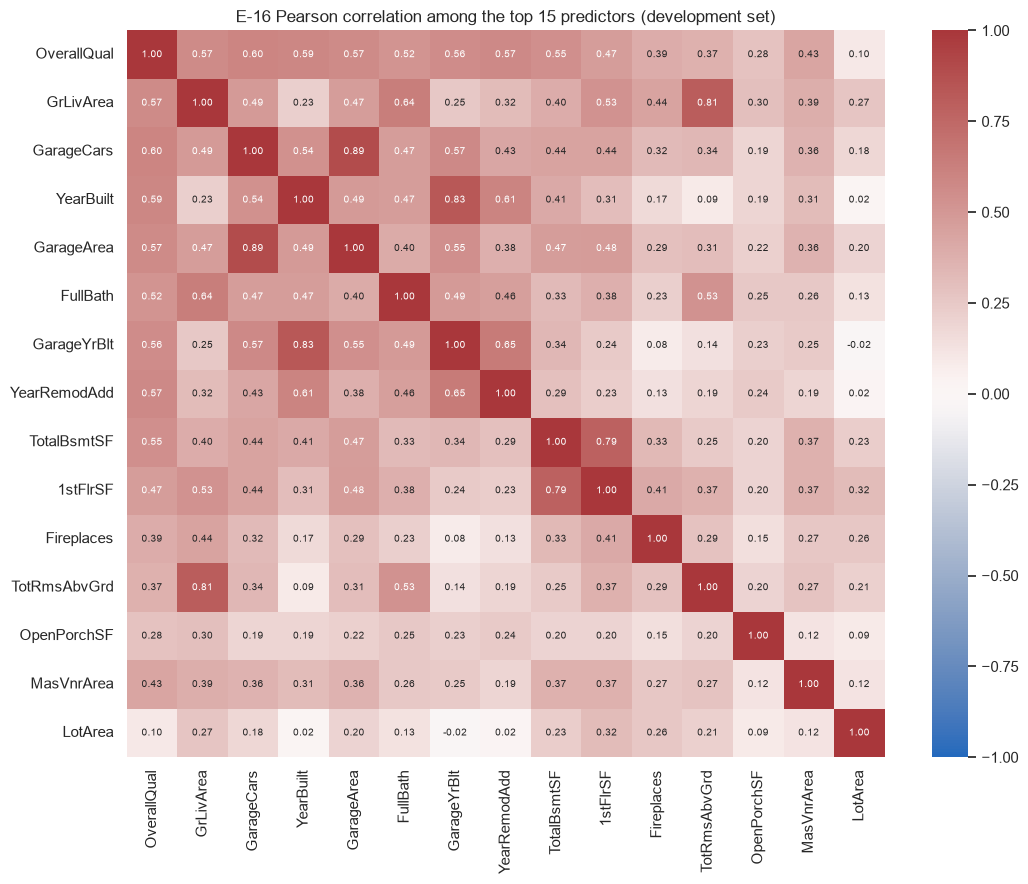

In [7]:
Image(filename=outputs.figures["E-16_correlation_heatmap"])

## E-17 Log price against the top predictors; OverallQual price profile.

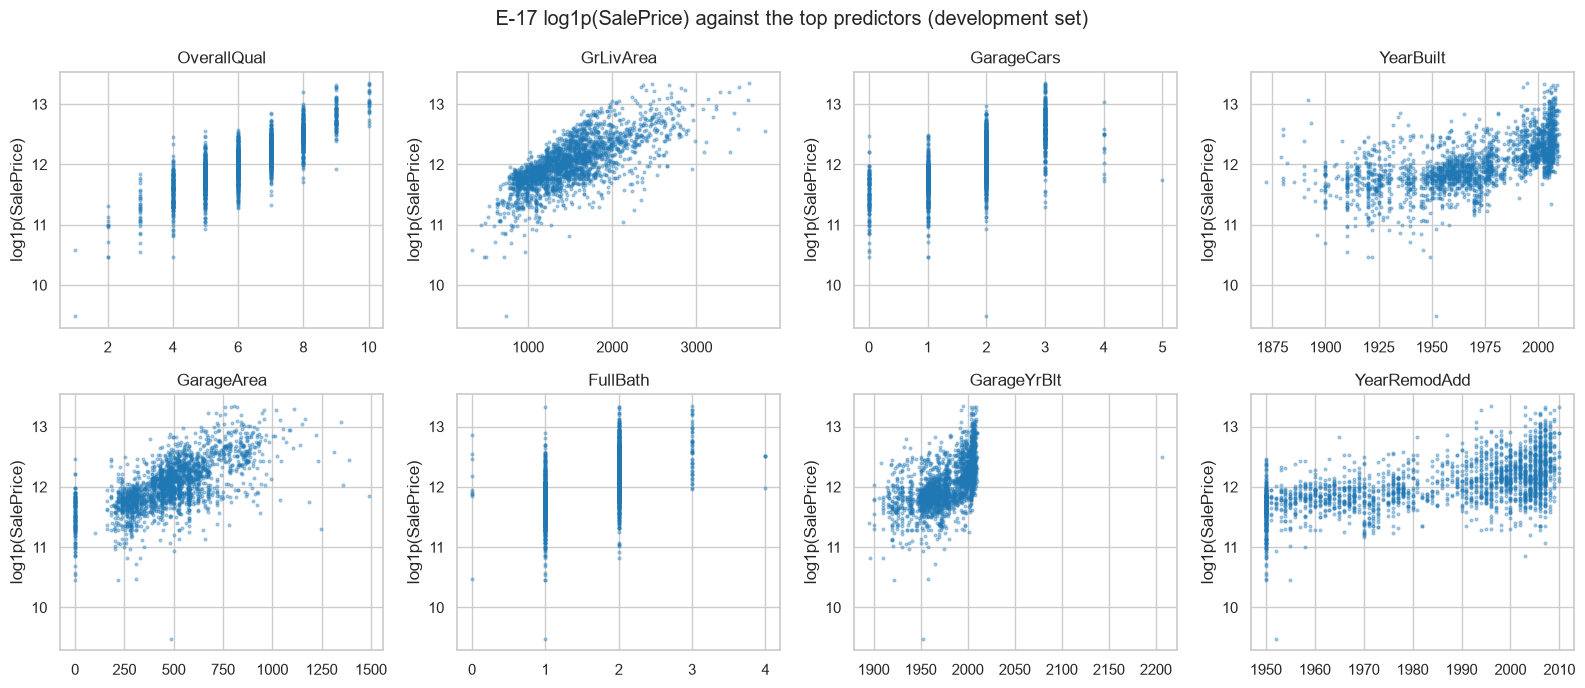

In [8]:
Image(filename=outputs.figures["E-17_top_predictor_scatter"])

In [9]:
outputs.tables["E-17_overallqual_price_profile"]

,OverallQual,n,median_price,median_log_price
0,1,2,26200.0,10.029725
1,2,10,59500.0,10.993713
2,3,31,79000.0,11.277216
3,4,193,107000.0,11.580593
4,5,657,132500.0,11.794345
5,6,586,159700.0,11.981058
6,7,480,199950.0,12.205828
7,8,269,267916.0,12.498433
8,9,89,356383.0,12.783764
9,10,23,451950.0,13.021329


## E-18 Values beyond the 99th percentile, with a legitimacy assessment.

In [10]:
outputs.tables["E-18_numeric_extremes"]

,feature,p99,n_above_p99,max,ids_above_p99,assessment
0,GrLivArea,2862.93,24,3820.0,1498|2446|2667|2451|1307|1538|2195|2331|16|66|...,legitimate: within schema physical range; cons...
1,LotArea,34389.87,24,215245.0,957|2116|2072|2767|315|1611|16|1403|2117|1638|...,legitimate: within schema physical range; cons...
2,LotFrontage,135.86,20,313.0,1266|2279|1639|496|2571|2322|2925|1631|2119|26...,legitimate: within schema physical range; cons...
3,TotalBsmtSF,2136.00,23,3206.0,445|1773|424|47|1638|433|1696|1064|380|457|186...,within schema range; related-column flags: 445...
4,1stFlrSF,2269.37,24,3820.0,1498|1773|1573|47|433|1696|380|350|2230|1861|4...,legitimate: within schema physical range; cons...
5,BsmtFinSF1,1601.06,24,2288.0,433|1064|45|514|457|1426|449|350|367|1614|2462...,legitimate: within schema physical range; cons...
6,GarageArea,1017.72,24,1488.0,1259|427|2283|1426|1028|1558|863|1053|747|367|...,legitimate: within schema physical range; cons...
7,MasVnrArea,764.62,24,1378.0,2446|1099|2259|102|1614|47|1183|2608|2337|499|...,legitimate: within schema physical range; cons...
8,WoodDeckSF,483.00,22,1424.0,2294|2451|2523|1489|2295|60|168|2119|2499|2736...,legitimate: within schema physical range; cons...
9,OpenPorchSF,276.44,24,570.0,2066|1289|727|1321|2244|2515|1498|1703|1343|17...,legitimate: within schema physical range; cons...
